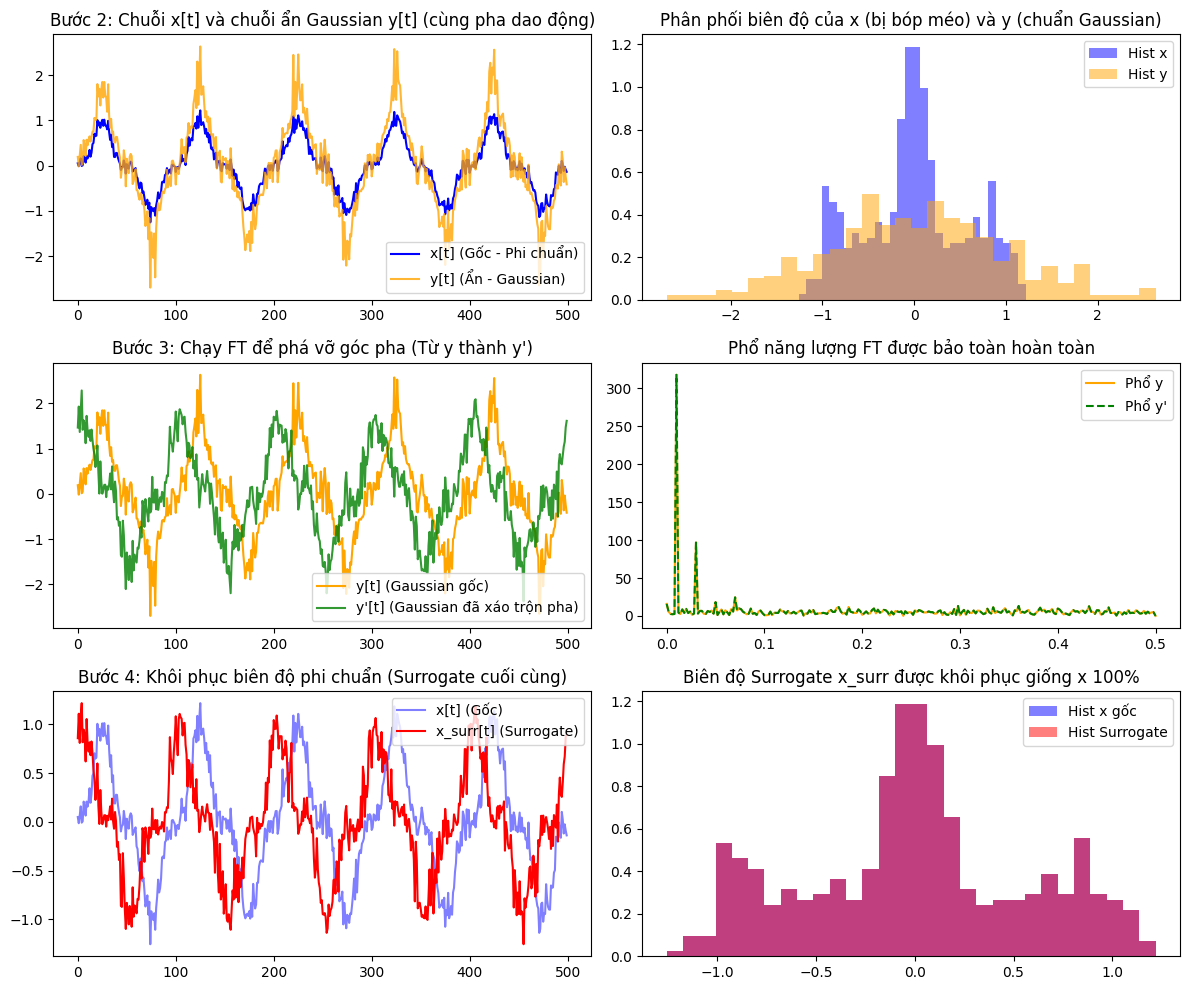

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# THIẾT LẬP DỮ LIỆU ĐẦU VÀO
# =====================================================================
np.random.seed(42)
N = 500
t = np.arange(N)

# Tạo tín hiệu phi chuẩn (Non-Gaussian): Sóng sin bị bóp méo (mũ 3) + nhiễu
x = (np.sin(2 * np.pi * t / 100))**3 + 0.1 * np.random.randn(N)

# =====================================================================
# THỰC THI AAFT STEP-BY-STEP
# =====================================================================

# Bước 1: Sinh chuỗi nhiễu Gaussian trắng độc lập
y_white = np.random.normal(0, 1, N)

# Bước 2: Lột màng lọc để tìm chuỗi ẩn y[t] (Ánh xạ h^-1)
# 2.1 Sắp xếp dữ liệu gốc x và lấy thứ tự hạng (ranks) của từng phần tử
ranks_x = np.argsort(np.argsort(x)) 

# 2.2 Sắp xếp chuỗi nhiễu Gaussian từ nhỏ đến lớn
sorted_y_white = np.sort(y_white)

# 2.3 Ép chuỗi Gaussian vào thứ tự thời gian của x
y = sorted_y_white[ranks_x]

# Bước 3: Phá hủy động lực học phi tuyến (Chạy module FT)
# 3.1 Biến đổi Fourier chuỗi y
fft_y = np.fft.rfft(y)
amplitudes = np.abs(fft_y)

# 3.2 Ngẫu nhiên hóa pha
random_phases = np.random.uniform(0, 2 * np.pi, len(fft_y))
random_phases[0] = 0.0
if N % 2 == 0:
    random_phases[-1] = 0.0

# 3.3 Biến đổi ngược để tạo chuỗi Surrogate trung gian y'
fft_surr = amplitudes * np.exp(1j * random_phases)
y_prime = np.fft.irfft(fft_surr, n=N)

# Bước 4: Khôi phục màng lọc biên độ (Ánh xạ h)
# 4.1 Lấy thứ tự hạng của chuỗi trung gian y'
ranks_y_prime = np.argsort(np.argsort(y_prime))

# 4.2 Sắp xếp dữ liệu gốc x từ nhỏ đến lớn
sorted_x = np.sort(x)

# 4.3 Ép dữ liệu gốc x vào thứ tự thời gian của y'
x_surr = sorted_x[ranks_y_prime]

# =====================================================================
# TRỰC QUAN HÓA (VISUALIZATION)
# =====================================================================
plt.figure(figsize=(12, 10))

# Đồ thị 1: So sánh dữ liệu gốc và chuỗi ẩn Gaussian (Bước 2)
plt.subplot(3, 2, 1)
plt.plot(x, label='x[t] (Gốc - Phi chuẩn)', color='blue')
plt.plot(y, label='y[t] (Ẩn - Gaussian)', color='orange', alpha=0.8)
plt.title('Bước 2: Chuỗi x[t] và chuỗi ẩn Gaussian y[t] (cùng pha dao động)')
plt.legend()

plt.subplot(3, 2, 2)
plt.hist(x, bins=30, alpha=0.5, color='blue', density=True, label='Hist x')
plt.hist(y, bins=30, alpha=0.5, color='orange', density=True, label='Hist y')
plt.title('Phân phối biên độ của x (bị bóp méo) và y (chuẩn Gaussian)')
plt.legend()

# Đồ thị 2: Sự phá vỡ góc pha trong miền Gaussian (Bước 3)
plt.subplot(3, 2, 3)
plt.plot(y, label='y[t] (Gaussian gốc)', color='orange')
plt.plot(y_prime, label="y'[t] (Gaussian đã xáo trộn pha)", color='green', alpha=0.8)
plt.title("Bước 3: Chạy FT để phá vỡ góc pha (Từ y thành y')")
plt.legend()

plt.subplot(3, 2, 4)
# Phổ năng lượng của y và y'
freqs = np.fft.rfftfreq(N)
plt.plot(freqs, np.abs(np.fft.rfft(y)), label='Phổ y', color='orange')
plt.plot(freqs, np.abs(np.fft.rfft(y_prime)), label="Phổ y'", color='green', linestyle='dashed')
plt.title("Phổ năng lượng FT được bảo toàn hoàn toàn")
plt.legend()

# Đồ thị 3: Khôi phục biên độ để ra Surrogate cuối cùng (Bước 4)
plt.subplot(3, 2, 5)
plt.plot(x, label='x[t] (Gốc)', color='blue', alpha=0.5)
plt.plot(x_surr, label='x_surr[t] (Surrogate)', color='red')
plt.title("Bước 4: Khôi phục biên độ phi chuẩn (Surrogate cuối cùng)")
plt.legend()

plt.subplot(3, 2, 6)
plt.hist(x, bins=30, alpha=0.5, color='blue', density=True, label='Hist x gốc')
plt.hist(x_surr, bins=30, alpha=0.5, color='red', density=True, label='Hist Surrogate')
plt.title('Biên độ Surrogate x_surr được khôi phục giống x 100%')
plt.legend()

plt.tight_layout()
plt.show()

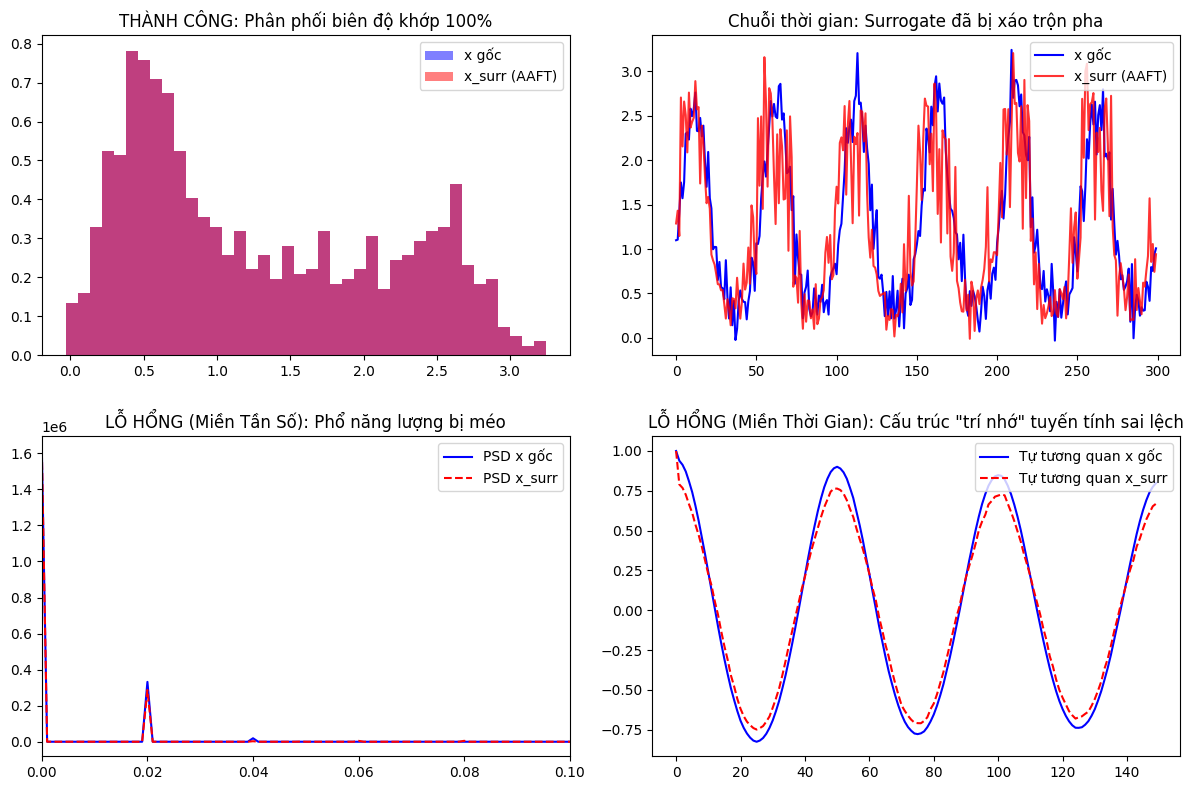

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# THIẾT LẬP DỮ LIỆU ĐẦU VÀO (TÍN HIỆU PHI CHUẨN MẠNH)
# =====================================================================
np.random.seed(42)
N = 1000
t = np.arange(N)

# Tạo tín hiệu có phổ Fourier rõ ràng nhưng phân phối biên độ rất phi chuẩn
# Sử dụng hàm e^x để tạo độ lệch (skewness) lớn, mô phỏng tín hiệu thực nghiệm
x = np.exp(np.sin(2 * np.pi * t / 50)) + 0.2 * np.random.randn(N)

# =====================================================================
# THỰC THI AAFT
# =====================================================================
# Bước 1 & 2: Lột màng lọc để tìm chuỗi ẩn y (Gaussian)
y_white = np.random.normal(0, 1, N)
ranks_x = np.argsort(np.argsort(x))
y = np.sort(y_white)[ranks_x]

# Bước 3: Phá hủy động lực học bằng FT (tạo chuỗi y')
fft_y = np.fft.rfft(y)
amplitudes = np.abs(fft_y)
random_phases = np.random.uniform(0, 2 * np.pi, len(fft_y))
random_phases[0] = 0.0
if N % 2 == 0:
    random_phases[-1] = 0.0
y_prime = np.fft.irfft(amplitudes * np.exp(1j * random_phases), n=N)

# Bước 4: Khôi phục màng lọc biên độ (Ánh xạ hạng cuối cùng)
ranks_y_prime = np.argsort(np.argsort(y_prime))
x_surr = np.sort(x)[ranks_y_prime]

# =====================================================================
# PHÂN TÍCH LỖ HỔNG (TÍNH TOÁN PHỔ VÀ TỰ TƯƠNG QUAN)
# =====================================================================
# 1. Tính Phổ năng lượng (Power Spectral Density - PSD)
freqs = np.fft.rfftfreq(N)
psd_x = np.abs(np.fft.rfft(x))**2
psd_surr = np.abs(np.fft.rfft(x_surr))**2

# 2. Tính Hàm tự tương quan (Autocorrelation)
def autocorrelation(signal):
    centered = signal - np.mean(signal)
    autocorr = np.correlate(centered, centered, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    return autocorr / autocorr[0]

autocorr_x = autocorrelation(x)
autocorr_surr = autocorrelation(x_surr)

# =====================================================================
# TRỰC QUAN HÓA (VISUALIZATION)
# =====================================================================

plt.figure(figsize=(12, 8))

# Đồ thị 1: Bằng chứng về "Chiếc áo biên độ hoàn hảo"
plt.subplot(2, 2, 1)
plt.hist(x, bins=40, alpha=0.5, color='blue', density=True, label='x gốc')
plt.hist(x_surr, bins=40, alpha=0.5, color='red', density=True, label='x_surr (AAFT)')
plt.title('THÀNH CÔNG: Phân phối biên độ khớp 100%')
plt.legend()

# Đồ thị 2: Chuỗi thời gian (Trực quan sự khác biệt)
plt.subplot(2, 2, 2)
plt.plot(t[:300], x[:300], label='x gốc', color='blue')
plt.plot(t[:300], x_surr[:300], label='x_surr (AAFT)', color='red', alpha=0.8)
plt.title('Chuỗi thời gian: Surrogate đã bị xáo trộn pha')
plt.legend()

# Đồ thị 3: LỖ HỔNG CHÍ MẠNG - Phổ năng lượng bị méo
plt.subplot(2, 2, 3)
plt.plot(freqs, psd_x, label='PSD x gốc', color='blue')
plt.plot(freqs, psd_surr, label='PSD x_surr', color='red', linestyle='--')
plt.title('LỖ HỔNG (Miền Tần Số): Phổ năng lượng bị méo')
plt.xlim(0, 0.1) # Zoom vào dải tần số thấp để thấy rõ sai lệch
plt.legend()

# Đồ thị 4: LỖ HỔNG CHÍ MẠNG - Tự tương quan bị lệch
plt.subplot(2, 2, 4)
plt.plot(autocorr_x[:150], label='Tự tương quan x gốc', color='blue')
plt.plot(autocorr_surr[:150], label='Tự tương quan x_surr', color='red', linestyle='--')
plt.title('LỖ HỔNG (Miền Thời Gian): Cấu trúc "trí nhớ" tuyến tính sai lệch')
plt.legend()

plt.tight_layout()
plt.show()